# BPA Master Workflow: Pattern Classification (Task 1) & TSD Estimation (Task 2)
**Toronto Metropolitan University — Major Research Project (MRP)**

---

## 🩸 Project Overview & Scientific Workflow
This master notebook coordinates the end-to-end execution of both core tasks in the Major Research Project:
1. **Task 1: Multi-Task Bloodstain Pattern Classification**: Predicts pattern categories (excluding Cough Spatter to prevent leakage) and physical force mechanisms, leading to physics-based Area of Origin calculations.
2. **Task 2: Time Since Deposition (TSD) Estimation**: Predicts temporal age splits (*Fresh*, *Intermediate*, *Aged*) based on hemoglobin oxidation color-space shifts over a 28-day drying cycle.

---

## ⚙️ Phase 1: Environment Setup & GPU Verification
Installs required libraries and checks if a high-speed GPU (T4 on Google Colab) is active.

In [1]:
# Check GPU acceleration
import torch
print('\n=== GPU Device Check ===')
if torch.cuda.is_available():
    print(f'[+] GPU Active: {torch.cuda.get_device_name(0)}')
else:
    print('[!] GPU not active. Running training from scratch is highly recommended with GPU support.')


=== GPU Device Check ===
[+] GPU Active: Tesla T4


In [2]:
# Install required dependencies
!pip install -q timm scikit-learn seaborn matplotlib python-docx albumentations jinja2
print('[+] Dependency libraries installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 19.3 MB/s eta 0:00:00
[+] Dependency libraries installed successfully!


---
## 🎯 Option A: Run Inference Using Saved Models
If you want to immediately run evaluations or test individual images using the pre-trained weights already saved in the repository, use this section. No training from scratch is required.

### 📂 Step A.1: Navigate to Repository Root
To run imports, load weight files, and access datasets, Colab needs to be pointing to the repository's root folder. Choose one of the options below:

#### 🌐 Option 1: Clone directly to Colab Local VM (Recommended for Reviewers)
This clones the code repository directly from GitHub into Colab's high-speed local VM storage. 

#### 💾 Option 2: Mount Personal Google Drive (Recommended for persistent development)
1. Open the 👉 **[Shared Google Drive Archive Link](https://drive.google.com/drive/folders/1Qg8CjBzJ2wPJIfGgGEfSezEaNndCxuGy?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto)**
2. Right-click the folder and select **Add shortcut to Drive** $\rightarrow$ select **My Drive**.
3. Run the code cell below with the **Method 2** lines uncommented to mount your Drive and navigate directly to it.

In [9]:
import os
import sys

# =====================================================================
# METHOD 1: Clone Directly to Colab Local VM (Easiest for anyone)
# =====================================================================
# Uncomment the two lines below to clone and cd to the repo root:
# !git clone https://github.com/shahidabatool/A-Hybrid-Framework-for-Forensic-Bloodstain-Pattern-Analysis.git
# %cd A-Hybrid-Framework-for-Forensic-Bloodstain-Pattern-Analysis

# =====================================================================
# METHOD 2: Mount Personal Google Drive (Recommended for persistent development)
# =====================================================================
# First, open the Shared Drive Link and select 'Add shortcut to Drive' on the parent folder.
# Then, uncomment the three lines below to mount and navigate directly to it:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/A-Hybrid-Framework-for-Forensic-Bloodstain-Pattern-Analysis/MRP
except ImportError:
    print('[+] Running in local terminal environment.')

print(f'[+] Current Working Directory set to: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/A-Hybrid-Framework-for-Forensic-Bloodstain-Pattern-Analysis/MRP
[+] Current Working Directory set to: /content/drive/MyDrive/A-Hybrid-Framework-for-Forensic-Bloodstain-Pattern-Analysis/MRP


### ⚠️ Notice: Pre-trained Weights Download
Because deep learning weight checkpoints (`.pth` files) are large and exceed GitHub's 100MB file limit, they are excluded from the git push commits.

- **If using Method 1 (Git Clone)**: Please download the `.pth` weights from the [Shared Google Drive Archive](https://drive.google.com/drive/folders/1Qg8CjBzJ2wPJIfGgGEfSezEaNndCxuGy?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto and upload them manually into the respective local Colab folders (`Task_1_Classification/Models/` and `Task_2_TSD/Models/`).
- **If using Method 2 (Drive Mount)**: Because you added a shortcut to your Drive (or cloned it inside your Drive), all weights and datasets inside `MRP` are already loaded and ready in your directory! No downloads or uploads are required.

### Step A.2: Import Architectures & Load Weights
This dynamically appends the correct model directories relative to your current workspace root folder.

In [11]:
import sys
import torch
import torchvision.transforms as transforms
from PIL import Image
import os

# Dynamically append import folders relative to current working directory
sys.path.append(os.path.join(os.getcwd(), 'Task_1_Classification/Code/training'))
sys.path.append(os.path.join(os.getcwd(), 'Task_2_TSD/Code/models'))

from train_efficientnet import BPAMultiTaskEfficientNet
from bloodnet import bloodnet50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[+] Using device: {device}')

# 1. Load Task 1 Classifier Model
t1_model = BPAMultiTaskEfficientNet(num_pattern=4, num_mechanism=3)
t1_weights_path = 'Task_1_Classification/Models/model1_efficientnet_b0.pth'
if os.path.exists(t1_weights_path):
    t1_model.load_state_dict(torch.load(t1_weights_path, map_location=device))
    t1_model.to(device).eval()
    print('[+] Task 1 (EfficientNet-B0) weights loaded successfully!')
else:
    print(f'[!] Warning: Weights file not found at {t1_weights_path}')

# 2. Load Task 2 TSD Model
t2_model = bloodnet50(num_classes=3)
t2_weights_path = 'Task_2_TSD/Models/best_tsd_model_resnet50.pth'
if os.path.exists(t2_weights_path):
    t2_model.load_state_dict(torch.load(t2_weights_path, map_location=device))
    t2_model.to(device).eval()
    print('[+] Task 2 (ResNet-50 CBAM) weights loaded successfully!')
else:
    print(f'[!] Warning: Weights file not found at {t2_weights_path}')


Running in Google Colab environment.
Auto-detected workspace directory in Google Drive: /content/drive/MyDrive/Task_1_Classification
[*] Using data directory: /content/drive/MyDrive/Task_1_Classification/Data/Augmented
Using device: cuda
Data Directory: /content/drive/MyDrive/Task_1_Classification/Data/Augmented
[+] Using device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

[+] Task 1 (EfficientNet-B0) weights loaded successfully!
[+] Task 2 (ResNet-50 CBAM) weights loaded successfully!


### 📊 Step A.2.b: Visualize Pre-trained Model Evaluation Metrics
This cell loads and displays the pre-generated evaluation plots (Confusion Matrices and ROC-AUC Curves) for both the Task 1 (EfficientNet-B0) and Task 2 (ResNet-50 CBAM) models. This allows you to verify the models' historical validation performance immediately without training them from scratch.

[+] Loading evaluation metrics and curves...


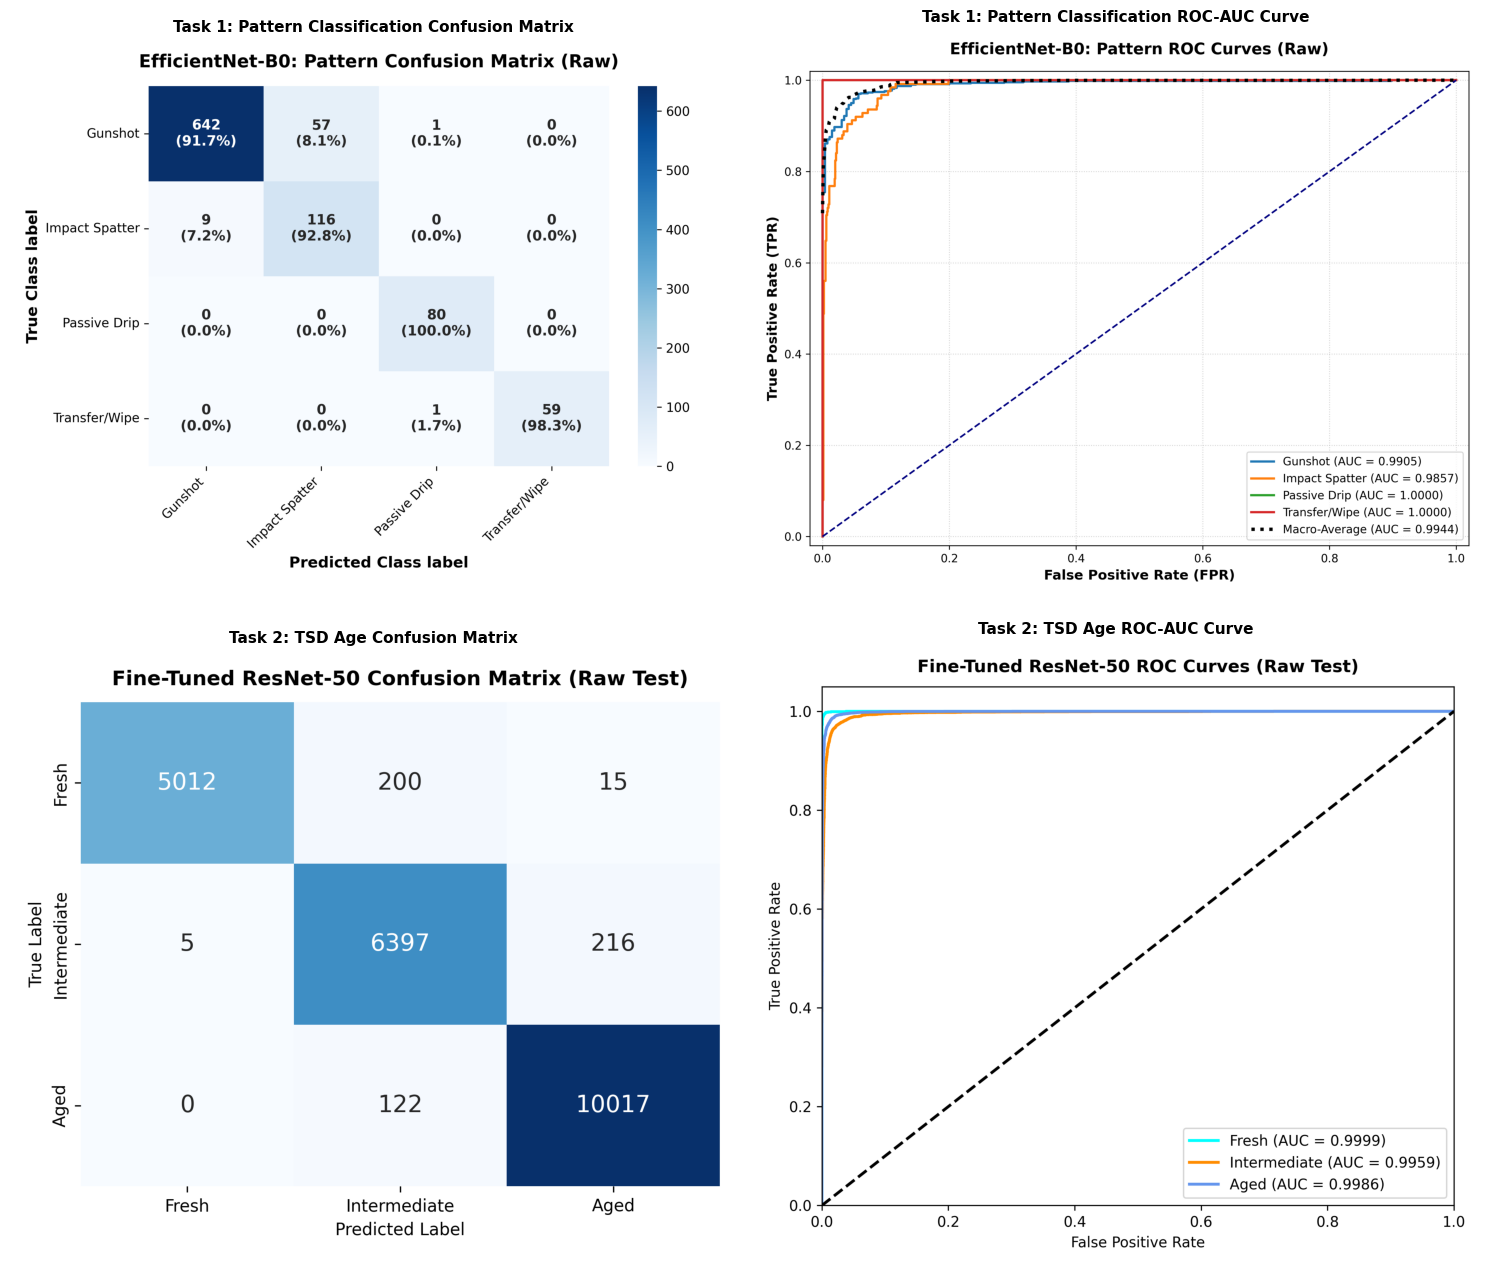

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Setup the paths to the pre-generated evaluation plots
t1_cm_path = 'Task_1_Classification/Evaluation/efficientnet_pattern_confusion_matrix.png'
t1_roc_path = 'Task_1_Classification/Evaluation/efficientnet_pattern_roc_auc.png'
t2_cm_path = 'Task_2_TSD/Evaluation/resnet50_tsd_confusion_matrix.png'
t2_roc_path = 'Task_2_TSD/Evaluation/resnet50_tsd_roc_auc.png'

paths = [t1_cm_path, t1_roc_path, t2_cm_path, t2_roc_path]
existing_paths = [p for p in paths if os.path.exists(p)]

if len(existing_paths) == 4:
    print("[+] Loading evaluation metrics and curves...")
    fig, axes = plt.subplots(2, 2, figsize=(15, 13))

    # Task 1 - Confusion Matrix
    axes[0, 0].imshow(mpimg.imread(t1_cm_path))
    axes[0, 0].set_title("Task 1: Pattern Classification Confusion Matrix", fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')

    # Task 1 - ROC Curve
    axes[0, 1].imshow(mpimg.imread(t1_roc_path))
    axes[0, 1].set_title("Task 1: Pattern Classification ROC-AUC Curve", fontsize=11, fontweight='bold')
    axes[0, 1].axis('off')

    # Task 2 - Confusion Matrix
    axes[1, 0].imshow(mpimg.imread(t2_cm_path))
    axes[1, 0].set_title("Task 2: TSD Age Confusion Matrix", fontsize=11, fontweight='bold')
    axes[1, 0].axis('off')

    # Task 2 - ROC Curve
    axes[1, 1].imshow(mpimg.imread(t2_roc_path))
    axes[1, 1].set_title("Task 2: TSD Age ROC-AUC Curve", fontsize=11, fontweight='bold')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("[!] Could not load all evaluation plots. Running diagnostic check on paths:")
    for p in paths:
        print(f" - {p}: {'FOUND' if os.path.exists(p) else 'MISSING'}")


### Step A.3: Run Unified Inference Example
Evaluate any custom bloodstain image path, printing out the predictions.

In [21]:
from IPython.display import display
import torch

def predict_bloodstain(image_path):
    if not os.path.exists(image_path):
        print(f'[!] File not found: {image_path}')
        print("Please verify the image path or try pointing to another image.")
        return

    # Preprocessing transforms
    t1_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    t2_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and display the image
    img = Image.open(image_path).convert('RGB')
    print("📸 Input Bloodstain Image:")
    display(img.resize((256, 256))) # Resized visually for clean display

    # Task 1 Classification
    img_t1 = t1_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        # Get the output dictionary
        t1_out = t1_model(img_t1)
        # Extract the specific tensors from the dictionary
        pattern_out = t1_out['pattern']
        mech_out = t1_out['mechanism']

        pattern_idx = torch.argmax(pattern_out, dim=1).item()
        mech_idx = torch.argmax(mech_out, dim=1).item()

    # Sourced active 4-class labels matching training output layer
    t1_pattern_labels = ['Gunshot', 'Impact Spatter', 'Passive Drip', 'Transfer/Wipe']
    t1_mech_labels = ['Passive', 'Low Velocity', 'Medium/High Velocity']

    # Task 2 Temporal Age Prediction
    img_t2 = t2_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        age_out = t2_model(img_t2)
        age_idx = torch.argmax(age_out, dim=1).item()

    t2_age_labels = ['Fresh (1 Day)', 'Intermediate (7-14 Days)', 'Aged (21-28 Days)']

    print('\n==================================================')
    print(f'🩸 FORENSIC ANALYSIS REPORT FOR: {os.path.basename(image_path)}')
    print('==================================================')
    print(f'[+] Predicted Pattern:    {t1_pattern_labels[pattern_idx]}')
    print(f'[+] Predicted Mechanism:  {t1_mech_labels[mech_idx]}')
    print(f'[+] Estimated Age (TSD):  {t2_age_labels[age_idx]}')
    print('==================================================')


### 🎯 Step A.3.b: Run Inference on Your Uploaded Image
This cell executes the prediction pipeline on your custom uploaded image. By default, it searches for a file named `sample.jpeg` in your current working directory or the root `/content` directory (where Colab file uploads are stored by default when using the left sidebar).

[+] Running predictions on: sample.jpeg

📸 Input Bloodstain Image:


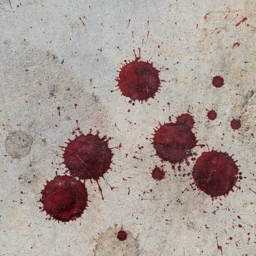


🩸 FORENSIC ANALYSIS REPORT FOR: sample.jpeg
[+] Predicted Pattern:    Passive Drip
[+] Predicted Mechanism:  Passive
[+] Estimated Age (TSD):  Fresh (1 Day)


In [ ]:
import os

# Smart path check for sample.jpeg
possible_paths = [
    'sample.jpeg',                     # Project folder
    'sample.jpg',
    '/content/sample.jpeg',            # Colab sidebar root
    '/content/sample.jpg'
]

test_image_path = None
for path in possible_paths:
    if os.path.exists(path):
        test_image_path = path
        break

if test_image_path:
    print(f"[+] Running predictions on: {test_image_path}\n")
    predict_bloodstain(test_image_path)
else:
    print("[!] Error: Could not locate 'sample.jpeg' anywhere.")
    print("Please upload your image to the left Colab files sidebar and name it exactly 'sample.jpeg'.")


---
## ⚙️ Option B: Re-run Training & Evaluation Pipelines
If you want to re-run the entire training cycle (e.g. on Colab virtual disk for faster speeds), follow this section.

### Step B.1: Extract Datasets from Google Drive
Extracts datasets to local high-speed VM storage to maximize training speed. Make sure you mount your Drive and set paths accordingly.

### Step B.2: Run Parent-Image Leakage Audit (Task 1)

In [25]:
!python Task_1_Classification/Code/preprocessing/audit_data_leakage.py

[*] Using data directory: /content/drive/MyDrive/Task_1_Classification/Data/Augmented
  BPA TASK 1 — PARENT-IMAGE LEAKAGE AUDIT REPORT

Audit checks whether the same source scan / video appears in
both the training and the test set (parent-image leakage).

DECISION: Cough_Spatter is EXCLUDED from evaluation because
it has only ONE source video and both train and test frames
originate from that same recording — a known dataset limitation.

----------------------------------------------------------------------

Class: Cough_Spatter
  Train sources  : 1
  Test sources   : 1
  Shared sources : 1
  Status         : ⚠  LEAKAGE DETECTED
  Leaking sources:
    - 15Aa2 Coughed blood

Class: Gunshot
  Train sources  : 108
  Test sources   : 28
  Shared sources : 0
  Status         : ✓  CLEAN

Class: Impact_Spatter
  Train sources  : 158
  Test sources   : 37
  Shared sources : 0
  Status         : ✓  CLEAN

Class: Passive_Drip
  Train sources  : 3
  Test sources   : 1
  Shared sources : 0
  Stat

### Step B.3: Train Task 1 Convolutional Models

In [ ]:
print('=== Training Multi-Task EfficientNet-B0 ===')
!python /content/Code/train_efficientnet.py --data_dir /content/Task_1/Data/Augmented/train --val_dir /content/Task_1/Data/Augmented/val --epochs 10 --batch_size 32

print('\n=== Training Multi-Task ResNet-50 ===')
!python /content/Code/train_resnet50.py --data_dir /content/Task_1/Data/Augmented/train --val_dir /content/Task_1/Data/Augmented/val --epochs 10 --batch_size 32

print('\n=== Training Multi-Task ConvNeXt-Tiny ===')
!python /content/Code/train_convnext.py

### Step B.4: Evaluate Task 1 Classifiers

In [ ]:
print('=== Evaluating EfficientNet-B0 ===')
!python /content/Code/evaluate_efficientnet.py --test_dir /content/Task_1/Data/Augmented/test

print('\n=== Evaluating ResNet-50 ===')
!python /content/Code/evaluate_resnet50.py --test_dir /content/Task_1/Data/Augmented/test

print('\n=== Evaluating ConvNeXt-Tiny ===')
!python /content/Code/evaluate_convnext.py

### Step B.5: Train Task 2 (TSD) Models

In [ ]:
print('=== Training Fine-Tuned ResNet-50 TSD ===')
!python Task_2_TSD/Code/models/train_tsd_resnet50.py \
  --data_dir Task_2_TSD/Text/BloodNet_50k_Images/data/train1 \
  --val_dir Task_2_TSD/Text/BloodNet_50k_Images/data/test \
  --weights_path Task_2_TSD/Text/BloodNet_50k_Images/bloodnet50_new.pth \
  --output_dir Task_2_TSD/Models \
  --epochs 10 \
  --batch_size 128 \
  --lr 1e-4

print('\n=== Training EfficientNet-B0 TSD ===')
!python Task_2_TSD/Code/models/train_tsd_efficientnet.py \
  --data_dir Task_2_TSD/Text/BloodNet_50k_Images/data/train1 \
  --val_dir Task_2_TSD/Text/BloodNet_50k_Images/data/test \
  --output_dir Task_2_TSD/Models \
  --epochs 10 \
  --batch_size 128 \
  --lr 1e-4

print('\n=== Training ConvNeXt-Tiny TSD ===')
# 🧠 Added the missing 3rd model:
!python Task_2_TSD/Code/models/train_tsd_convnext.py \
  --data_dir Task_2_TSD/Text/BloodNet_50k_Images/data/train1 \
  --val_dir Task_2_TSD/Text/BloodNet_50k_Images/data/test \
  --output_dir Task_2_TSD/Models \
  --epochs 10 \
  --batch_size 128 \
  --lr 1e-4

### Step B.6: Evaluate Task 2 TSD Backbones

In [ ]:
!python Task_2_TSD/Code/evaluation/evaluate_tsd.py \
  --test_dir Task_2_TSD/Text/BloodNet_50k_Images/data/outside_test \
  --baseline_weights Task_2_TSD/Text/BloodNet_50k_Images/bloodnet50_new.pth \
  --resnet50_weights Task_2_TSD/Models/best_tsd_model_resnet50.pth \
  --efficientnet_weights Task_2_TSD/Models/best_tsd_model_efficientnet.pth \
  --convnext_weights Task_2_TSD/Models/best_tsd_model_convnext.pth \
  --output_dir Task_2_TSD/Evaluation

### Step B.7: Sync Checkpoints and Reports Back to Drive

In [ ]:
!python /content/Code/generate_word_report.py
!python /content/TSD_Code/generate_tsd_word_report.py

# Sync Task 1
!mkdir -p /content/drive/MyDrive/Task_1_Classification/Evaluation
!cp -r /content/Task_1/Evaluation/* /content/drive/MyDrive/Task_1_Classification/Evaluation/

# Sync Task 2
!mkdir -p /content/drive/MyDrive/Task_2_TSD/Evaluation
!mkdir -p /content/drive/MyDrive/Task_2_TSD/Models
!cp -r /content/Task_2/Evaluation/* /content/drive/MyDrive/Task_2_TSD/Evaluation/
!cp -r /content/Task_2/Models/* /content/drive/MyDrive/Task_2_TSD/Models/

print('[+] All checkpoints and Word reports synced to Google Drive successfully!')

---
## 💻 Phase 4: Run the Streamlit Dashboard (Local Execution)
To start the visual analytics interface on your local Mac/Windows machine, run these command line prompts:

```bash
# 1. Navigate to the project root directory
cd /path/to/cloned/repository/MRP

# 2. Activate the virtual environment
source mrp_env/bin/activate

# 3. Run the application server
streamlit run dashboard.py
```
This will launch the web application local instance at `http://localhost:8501`, loading models dynamically from the respective models folders.

---
## 🖥️ Streamlit Dashboard & Local Execution
For an interactive, user-friendly visualization of the decision support system, you can run the Streamlit dashboard locally on your machine. 

We have provided a double-clickable launch file: **`run_dashboard.command`** in the repository root.

### How to run the dashboard:
1. Locate **`run_dashboard.command`** in your project folder on your computer.
2. On **macOS**, simply **double-click** the file. It will automatically launch the terminal, activate the `mrp_env` virtual environment, and open the interactive Streamlit dashboard in your default browser.
3. On **Windows/Linux**, open your terminal in the project directory and run:
   ```bash
   source mrp_env/bin/activate
   streamlit run dashboard.py
   ```